In [2]:
import os

print(os.getcwd())
print(os.listdir())


c:\Users\thari\Downloads\Customer_segmentation project
['Online Retail.xlsx']


In [ ]:
import pandas as pd

data = pd.read_excel("Online Retail.xlsx")

print("Dataset Loaded Successfully!")
print(data.head())
print(data.columns)

Dataset Loaded Successfully!
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')


Dataset Loaded Successfully!

Customer Summary:
   CustomerID  Quantity  TotalAmount
0     12346.0         0         0.00
1     12347.0      2458      4310.00
2     12348.0      2341      1797.24
3     12349.0       631      1757.55
4     12350.0       197       334.40

Clustered Customers:
   CustomerID  Quantity  TotalAmount  Cluster
0     12346.0         0         0.00        0
1     12347.0      2458      4310.00        0
2     12348.0      2341      1797.24        0
3     12349.0       631      1757.55        0
4     12350.0       197       334.40        0

Customers in each cluster:
Cluster
0    4321
2      40
3       8
1       3
Name: count, dtype: int64


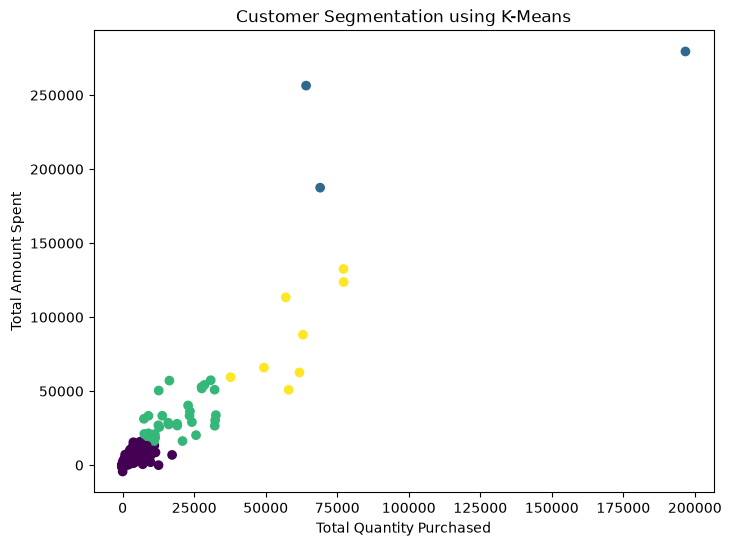

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
data = pd.read_excel("Online Retail.xlsx")
print("Dataset Loaded Successfully!")
data = data.dropna(subset=['CustomerID'])
data['TotalAmount'] = data['Quantity'] * data['UnitPrice']
customer_data = data.groupby('CustomerID').agg({
    'Quantity': 'sum',
    'TotalAmount': 'sum'
}).reset_index()

print("\nCustomer Summary:")
print(customer_data.head())
X = customer_data[['Quantity', 'TotalAmount']]
kmeans = KMeans(n_clusters=4, random_state=42)
customer_data['Cluster'] = kmeans.fit_predict(X)
print("\nClustered Customers:")
print(customer_data.head())
print("\nCustomers in each cluster:")
print(customer_data['Cluster'].value_counts())
plt.figure(figsize=(8,6))
plt.scatter(
    customer_data['Quantity'],
    customer_data['TotalAmount'],
    c=customer_data['Cluster']
)

plt.xlabel('Total Quantity Purchased')
plt.ylabel('Total Amount Spent')
plt.title('Customer Segmentation using K-Means')

plt.show()